# Machine Learning with PyTorch and Scikit-Learn  
# -- Code Examples

## Package version checks

Add folder to path in order to load from the check_packages.py script:

In [1]:
import sys
sys.path.insert(0, '..')

Check recommended package versions:

In [2]:
from python_environment_check import check_packages


d = {
    'numpy': '1.21.2',
    'scipy': '1.7.0',
    'sklearn': '1.0.0',
    'matplotlib': '3.4.3',
    'torch': '1.9.0',
}
check_packages(d)

[OK] Your Python version is 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
[OK] numpy 2.2.6
[OK] scipy 1.15.3
[OK] sklearn 1.6.1
[OK] matplotlib 3.10.3
[OK] torch 2.7.0+cpu


# Chapter 12: Parallelizing Neural Network Training with PyTorch  (Part 2/2)


- [Building an NN model in PyTorch](#Building-an-NN-model-in-PyTorch)
  - [The PyTorch neural network module (torch.nn)](#The-PyTorch-neural-network-module-(torch.nn))
  - [Building a linear regression model](#Building-a-linear-regression-model)
  - [Model training via the torch.nn and torch.optim modules](#Model-training-via-the-torch.nn-and-torch.optim-modules)
  - [Building a multilayer perceptron for classifying flowers in the Iris dataset](#Building-a-multilayer-perceptron-for-classifying-flowers-in-the-Iris-dataset)
  - [Evaluating the trained model on the test dataset](#Evaluating-the-trained-model-on-the-test-dataset)
  - [Saving and reloading the trained model](#Saving-and-reloading-the-trained-model)
- [Choosing activation functions for multilayer neural
networks](#Choosing-activation-functions-for-multilayer-neural-networks)
  - [Logistic function recap](#Logistic-function-recap)
  - [Estimating class probabilities in multiclass classification via the softmax function](#Estimating-class-probabilities-in-multiclass-classification-via-the-softmax-function)
  - [Broadening the output spectrum using a hyperbolic tangent](#Broadening-the-output-spectrum-using-a-hyperbolic-tangent)
  - [Rectified linear unit activation](#Rectified-linear-unit-activation)
- [Summary](#Summary)

Note that the optional watermark extension is a small IPython notebook plugin that I developed to make the code reproducible. You can just skip the following line(s).

In [1]:
from IPython.display import Image as IPythonImage
%matplotlib inline

## Building a neural network model in PyTorch

### The PyTorch neural network module (torch.nn)

### Building a linear regression model

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

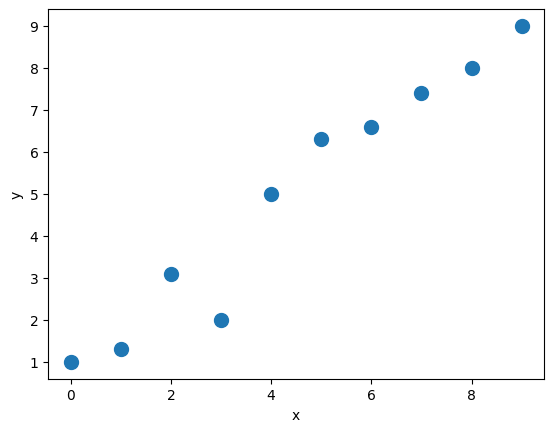

In [3]:
X_train = np.arange(10, dtype='float32').reshape((10, 1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0, 6.3, 6.6, 
                    7.4, 8.0, 9.0], dtype='float32')

plt.plot(X_train, y_train, 'o', markersize=10)
plt.xlabel('x')
plt.ylabel('y')

#plt.savefig('figures/12_07.pdf')
plt.show()

In [5]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm)

# On some computers the explicit cast to .float() is
# necessary
y_train = torch.from_numpy(y_train).float()

train_ds = TensorDataset(X_train_norm, y_train)

batch_size = 1
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [8]:
torch.manual_seed(1)
weight = torch.randn(1)
weight.requires_grad_()
bias = torch.zeros(1, requires_grad=True)
 
def loss_fn(input, target):
    return (input-target).pow(2).mean()

def model(xb):
    return xb @ weight + bias

learning_rate = 0.01
num_epochs = 200
log_epochs = 10

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()

        with torch.no_grad():
            weight -= weight.grad * learning_rate
            bias -= bias.grad * learning_rate
            weight.grad.zero_()
            bias.grad.zero_()
 
    if epoch % log_epochs==0:
        print(f'Epoch {epoch}  Loss {loss.item():.4f}')
 

Epoch 0  Loss 33.4174
Epoch 10  Loss 2.0990
Epoch 20  Loss 0.1277
Epoch 30  Loss 0.0701
Epoch 40  Loss 0.0491
Epoch 50  Loss 0.0071
Epoch 60  Loss 0.0859
Epoch 70  Loss 0.0500
Epoch 80  Loss 0.2555
Epoch 90  Loss 0.0759
Epoch 100  Loss 0.0511
Epoch 110  Loss 0.2577
Epoch 120  Loss 0.1506
Epoch 130  Loss 0.2483
Epoch 140  Loss 0.0493
Epoch 150  Loss 2.5503
Epoch 160  Loss 0.0773
Epoch 170  Loss 0.0058
Epoch 180  Loss 0.0056
Epoch 190  Loss 0.0448


Final Parameters: 2.7062716484069824 4.963663578033447


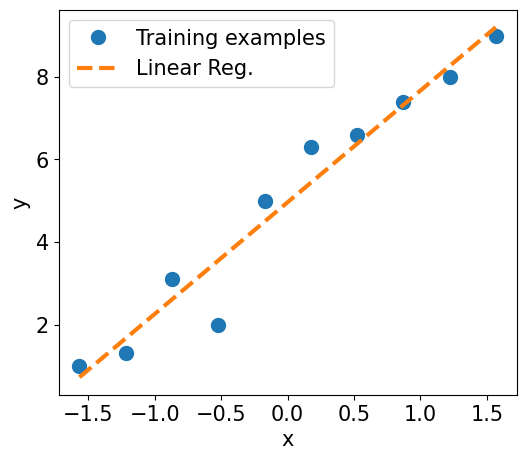

In [10]:
print('Final Parameters:', weight.item(), bias.item())
 
X_test = np.linspace(0, 9, num=10, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm).detach().numpy()


fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['Training examples', 'Linear Reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
 
#plt.savefig('figures/12_08.pdf')

plt.show()

In [17]:
train_dl.dataset[:]

(tensor([[-1.5667],
         [-1.2185],
         [-0.8704],
         [-0.5222],
         [-0.1741],
         [ 0.1741],
         [ 0.5222],
         [ 0.8704],
         [ 1.2185],
         [ 1.5667]]),
 tensor([1.0000, 1.3000, 3.1000, 2.0000, 5.0000, 6.3000, 6.6000, 7.4000, 8.0000,
         9.0000]))

In [43]:
n=50
lrse=[-0.2-(i/n*4) for i in range(n)]
lrs=[10**i for i in lrse]
lrs

[0.6309573444801932,
 0.5248074602497725,
 0.436515832240166,
 0.36307805477010135,
 0.3019951720402016,
 0.25118864315095796,
 0.20892961308540398,
 0.17378008287493754,
 0.1445439770745927,
 0.12022644346174131,
 0.1,
 0.08317637711026708,
 0.06918309709189366,
 0.057543993733715694,
 0.047863009232263824,
 0.039810717055349734,
 0.03311311214825911,
 0.02754228703338166,
 0.022908676527677734,
 0.019054607179632473,
 0.015848931924611134,
 0.013182567385564075,
 0.01096478196143185,
 0.009120108393559097,
 0.007585775750291836,
 0.00630957344480193,
 0.005248074602497723,
 0.004365158322401657,
 0.00363078054770101,
 0.003019951720402016,
 0.0025118864315095794,
 0.0020892961308540386,
 0.0017378008287493745,
 0.0014454397707459265,
 0.001202264434617412,
 0.001,
 0.0008317637711026709,
 0.0006918309709189362,
 0.0005754399373371566,
 0.00047863009232263805,
 0.0003981071705534969,
 0.0003311311214825911,
 0.0002754228703338166,
 0.00022908676527677723,
 0.00019054607179632462,
 0.0

### Model training via the torch.nn and torch.optim modules

In [44]:
import torch.nn as nn
#learning_rate=0.001
mse_out_lr=[]
for lrv in lrs:
    input_size = 1
    output_size = 1
    model = nn.Linear(input_size, output_size)

    loss_fn = nn.MSELoss(reduction='mean')

    optimizer = torch.optim.SGD(model.parameters(), lr=lrv)

    for epoch in range(num_epochs):
        for x_batch, y_batch in train_dl:
            # 1. Generate predictions
            pred = model(x_batch)[:, 0] 

            # 2. Calculate loss
            loss = loss_fn(pred, y_batch)

            # 3. Compute gradients
            loss.backward()

            # 4. Update parameters using gradients
            optimizer.step()

            # 5. Reset the gradients to zero
            optimizer.zero_grad()
            
        if epoch % log_epochs==0:
            print(f'Epoch {epoch}  Loss {loss.item():.4f}')
    mse_out_lr.append(loss.item())

Epoch 0  Loss 426.0619
Epoch 10  Loss 501982959763456.0000
Epoch 20  Loss 114264814389731665251401728.0000
Epoch 30  Loss 255106265303664026465342206037196800.0000
Epoch 40  Loss inf
Epoch 50  Loss inf
Epoch 60  Loss nan
Epoch 70  Loss nan
Epoch 80  Loss nan
Epoch 90  Loss nan
Epoch 100  Loss nan
Epoch 110  Loss nan
Epoch 120  Loss nan
Epoch 130  Loss nan
Epoch 140  Loss nan
Epoch 150  Loss nan
Epoch 160  Loss nan
Epoch 170  Loss nan
Epoch 180  Loss nan
Epoch 190  Loss nan
Epoch 0  Loss 11.3826
Epoch 10  Loss 115.7159
Epoch 20  Loss 115.9188
Epoch 30  Loss 745.6285
Epoch 40  Loss 14168780.0000
Epoch 50  Loss 39359356.0000
Epoch 60  Loss 6126.8325
Epoch 70  Loss 13.5191
Epoch 80  Loss 143.0174
Epoch 90  Loss 60.8892
Epoch 100  Loss 6.1991
Epoch 110  Loss 1577.9521
Epoch 120  Loss 2222.3391
Epoch 130  Loss 308.8076
Epoch 140  Loss 0.3799
Epoch 150  Loss 1.3164
Epoch 160  Loss 207.1496
Epoch 170  Loss 156.2092
Epoch 180  Loss 26054.1348
Epoch 190  Loss 20.0327
Epoch 0  Loss 0.7634
Epoch 1

In [45]:
mse_out_lr

[nan,
 4.0880126953125,
 1.3621679544448853,
 5.333236217498779,
 0.23169410228729248,
 0.08759073913097382,
 0.4831385910511017,
 0.09938161075115204,
 0.9616388082504272,
 0.1499023288488388,
 0.014902441762387753,
 0.10331262648105621,
 0.2716282606124878,
 0.33590587973594666,
 0.034951984882354736,
 0.27057480812072754,
 0.25336962938308716,
 0.08368509262800217,
 0.7788646221160889,
 0.159798726439476,
 0.04950936511158943,
 0.007049451116472483,
 0.0777299776673317,
 0.04834474250674248,
 0.15002992749214172,
 2.495941638946533,
 0.24250417947769165,
 0.07556972652673721,
 0.04592946171760559,
 0.048259858042001724,
 0.2406734973192215,
 0.25442731380462646,
 0.24198035895824432,
 0.2445509284734726,
 0.299525648355484,
 0.2970661520957947,
 2.1230177879333496,
 1.5694767236709595,
 1.0440913438796997,
 1.8243129253387451,
 3.2374331951141357,
 1.0552171468734741,
 6.085770130157471,
 10.765096664428711,
 0.03769610822200775,
 2.5029537677764893,
 9.149467468261719,
 40.87923812

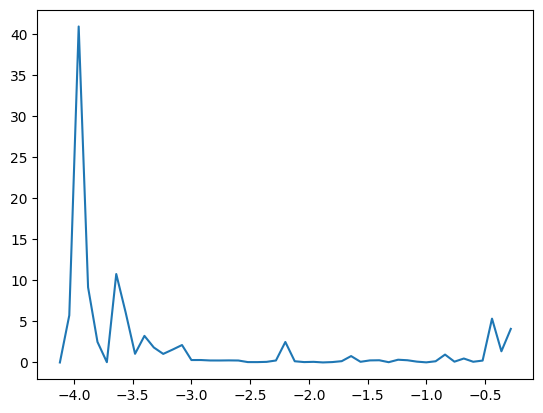

In [46]:
plt.plot(lrse,mse_out_lr)

Final Parameters: 0.6713520288467407 2.024688959121704


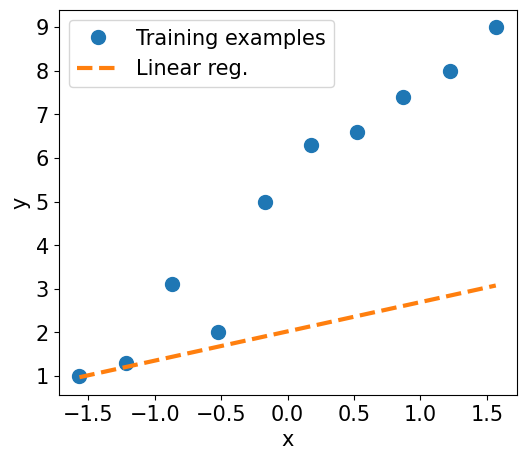

In [47]:
print('Final Parameters:', model.weight.item(), model.bias.item())
 
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm)


fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm.detach().numpy(), y_train.detach().numpy(), 'o', markersize=10)
plt.plot(X_test_norm.detach().numpy(), y_pred.detach().numpy(), '--', lw=3)
plt.legend(['Training examples', 'Linear reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
 
#plt.savefig('ch12-linreg-2.pdf')

plt.show()


## Building a multilayer perceptron for classifying flowers in the Iris dataset

In [48]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 

iris = load_iris()
X = iris['data']
y = iris['target']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1./3, random_state=1)

In [49]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train) 

train_ds = TensorDataset(X_train_norm, y_train)

torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [64]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)  
        self.layer2 = nn.Linear(hidden_size, output_size)  

    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        x = nn.Softmax(dim=1)(x)
        return x
    
input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3
 
model = Model(input_size, hidden_size, output_size)

learning_rate = 0.005

loss_fn = nn.CrossEntropyLoss()
 
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [65]:
num_epochs = 50
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs

In [66]:


for epoch in range(num_epochs):

    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch.long())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    
        loss_hist[epoch] += loss.item()*y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist[epoch] += is_correct.sum()
        
    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)

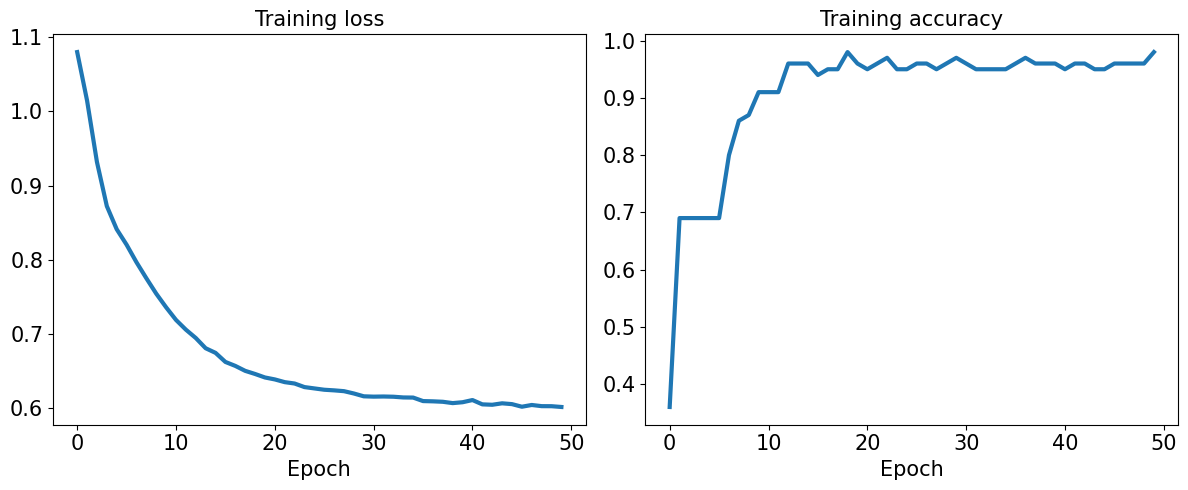

In [67]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()

#plt.savefig('figures/12_09.pdf')
 
plt.show()

### Evaluating the trained model on the test dataset

In [68]:
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test) 
pred_test = model(X_test_norm)

correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
 
print(f'Test Acc.: {accuracy:.4f}')


Test Acc.: 0.9800


### Saving and reloading the trained model

In [69]:
path = 'iris_classifier.pt'
torch.save(model, path)

In [70]:
model_new = torch.load(path,weights_only=False)
model_new.eval()

Model(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)

In [71]:
pred_test = model_new(X_test_norm)

correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
 
print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 0.9800


In [72]:
path = 'iris_classifier_state.pt'
torch.save(model.state_dict(), path)

In [73]:
model_new = Model(input_size, hidden_size, output_size)
model_new.load_state_dict(torch.load(path))


<All keys matched successfully>

## Choosing activation functions for multilayer neural networks


### Logistic function recap

In [22]:
import numpy as np

X = np.array([1, 1.4, 2.5]) ## first value must be 1
w = np.array([0.4, 0.3, 0.5])

def net_input(X, w):
    return np.dot(X, w)

def logistic(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_activation(X, w):
    z = net_input(X, w)
    return logistic(z)

print(f'P(y=1|x) = {logistic_activation(X, w):.3f}') 

P(y=1|x) = 0.888


In [23]:
# W : array with shape = (n_output_units, n_hidden_units+1)
# note that the first column are the bias units

W = np.array([[1.1, 1.2, 0.8, 0.4],
              [0.2, 0.4, 1.0, 0.2],
              [0.6, 1.5, 1.2, 0.7]])

# A : data array with shape = (n_hidden_units + 1, n_samples)
# note that the first column of this array must be 1

A = np.array([[1, 0.1, 0.4, 0.6]])
Z = np.dot(W, A[0])
y_probas = logistic(Z)
print('Net Input: \n', Z)

print('Output Units:\n', y_probas) 

Net Input: 
 [1.78 0.76 1.65]
Output Units:
 [0.85569687 0.68135373 0.83889105]


In [24]:
y_class = np.argmax(Z, axis=0)
print('Predicted class label:', y_class) 

Predicted class label: 0


### Estimating class probabilities in multiclass classification via the softmax function

In [25]:
def softmax(z):
    return np.exp(z) / np.sum(np.exp(z))

y_probas = softmax(Z)
print('Probabilities:\n', y_probas)

np.sum(y_probas)

Probabilities:
 [0.44668973 0.16107406 0.39223621]


1.0

In [26]:
torch.softmax(torch.from_numpy(Z), dim=0)

tensor([0.4467, 0.1611, 0.3922], dtype=torch.float64)

### Broadening the output spectrum using a hyperbolic tangent

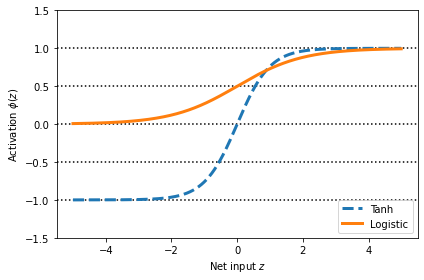

In [27]:
import matplotlib.pyplot as plt
%matplotlib inline

def tanh(z):
    e_p = np.exp(z)
    e_m = np.exp(-z)
    return (e_p - e_m) / (e_p + e_m)

z = np.arange(-5, 5, 0.005)
log_act = logistic(z)
tanh_act = tanh(z)
plt.ylim([-1.5, 1.5])
plt.xlabel('Net input $z$')
plt.ylabel('Activation $\phi(z)$')
plt.axhline(1, color='black', linestyle=':')
plt.axhline(0.5, color='black', linestyle=':')
plt.axhline(0, color='black', linestyle=':')
plt.axhline(-0.5, color='black', linestyle=':')
plt.axhline(-1, color='black', linestyle=':')
plt.plot(z, tanh_act,
    linewidth=3, linestyle='--',
    label='Tanh')
plt.plot(z, log_act,
    linewidth=3,
    label='Logistic')
plt.legend(loc='lower right')
plt.tight_layout()

#plt.savefig('figures/12_10.pdf')
plt.show()

In [28]:
np.tanh(z)

array([-0.9999092 , -0.99990829, -0.99990737, ...,  0.99990644,
        0.99990737,  0.99990829])

In [29]:
torch.tanh(torch.from_numpy(z))
 

tensor([-0.9999, -0.9999, -0.9999,  ...,  0.9999,  0.9999,  0.9999],
       dtype=torch.float64)

In [30]:
from scipy.special import expit

expit(z)

array([0.00669285, 0.00672617, 0.00675966, ..., 0.99320669, 0.99324034,
       0.99327383])

In [31]:
torch.sigmoid(torch.from_numpy(z))

tensor([0.0067, 0.0067, 0.0068,  ..., 0.9932, 0.9932, 0.9933],
       dtype=torch.float64)

### Rectified linear unit activation

In [32]:
torch.relu(torch.from_numpy(z))

tensor([0.0000, 0.0000, 0.0000,  ..., 4.9850, 4.9900, 4.9950],
       dtype=torch.float64)

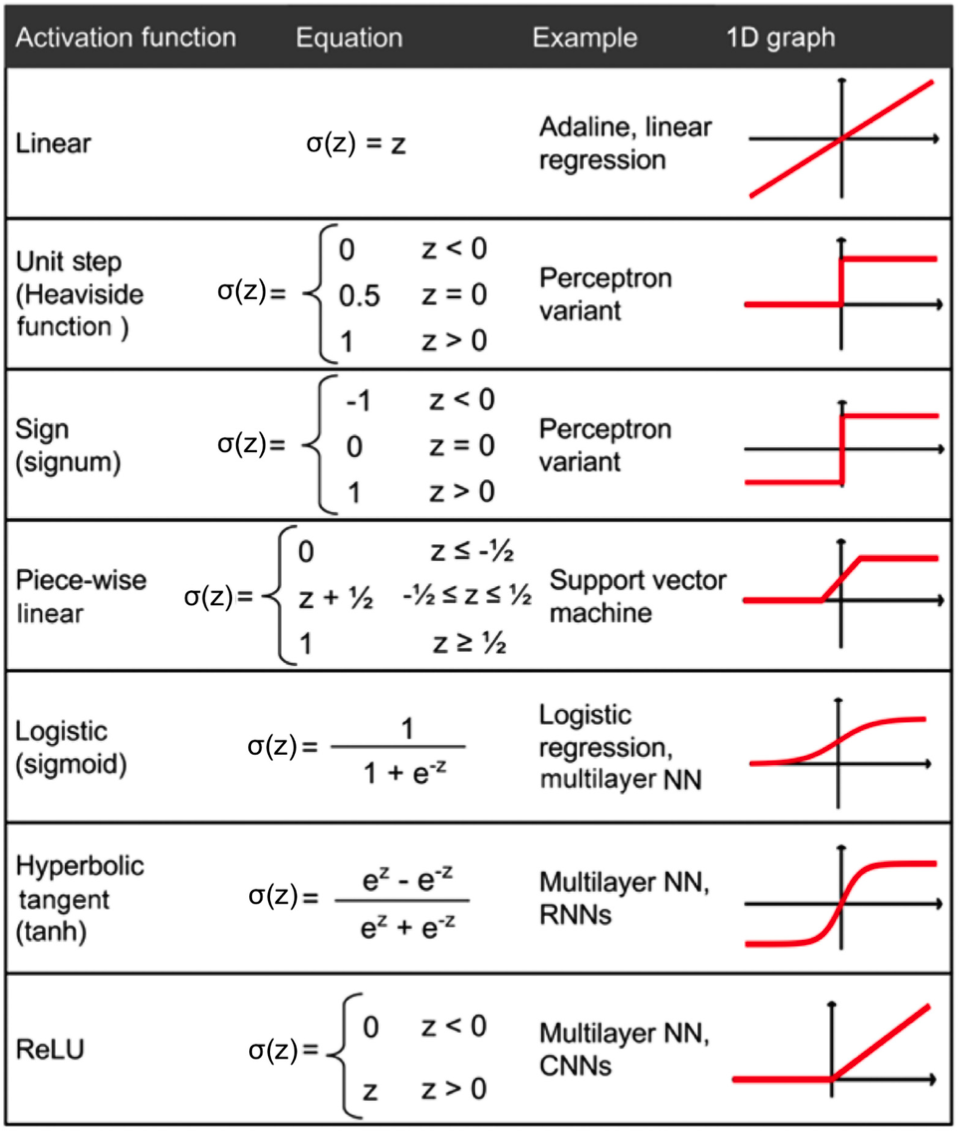

In [33]:
IPythonImage(filename='figures/12_11.png', width=500)

## Summary

---

Readers may ignore the next cell.

In [34]:
! python ../.convert_notebook_to_script.py --input ch12_part2.ipynb --output ch12_part2.py

[NbConvertApp] Converting notebook ch12_part2.ipynb to script
[NbConvertApp] Writing 12165 bytes to ch12_part2.py
